In [1]:
import xarray as xr
import os
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [2]:
# Results directory
results_directory = './v10_1_results/'

# Start and end years for the future climate period
start_year= 1981
end_year= 2015

# Start and end years for historical climate period
hist_start= 1981
hist_end= 2015

# HYPE output variable
variable= 'fcon' 

# Path to HYPE output files
mreib_historical_path= '../../SMM_Models/hype/model/v10_model/final_model/hds_v1/results/0058308.txt'
smrib_historical_path= '../../SMM_Models/hype/model/v10_model/final_model/hds_v1/results/0058208.txt'

# Output directory for plots
output_directory= './outputs/'

In [3]:
def extract_ensemble(results_directory: str, subbasin_id: str, variable= 'cout', exclude_members=True):
    """
    Extracts ensemble data from files, filters by subbasin ID, and optionally excludes members not found in the offical ensemble.

    Parameters:
        results_directory (str): Path to the directory containing result files.
        subbasin_id (str): Identifier for filtering files belonging to a specific subbasin.
        exclude_members (bool): If True, excludes specified model members.

    Returns:
        xarray.DataArray: Combined ensemble data as an xarray DataArray.
    """
    # List of model names to exclude (not in official ensemble)
    exclude_models = [
        'CanESM5', 'CNRM-CM6-1', 'EC-Earth3', 'IPSL-CM6A-LR',
        'UKESM1-0-LL', 'NorESM2-MM', 'EC-Earth3-CC', 'NESM3',
        'EC-Earth3-Veg', 'INM-CM4-8', 'TaiESM1'
    ]
    
    # Check for files of required subbasin_id
    file_list = [os.path.join(results_directory, filename) for filename in os.listdir(results_directory)
                 if subbasin_id in filename]  # Only filter by subbasin_id
    
    # Create an empty list to store xarray DataArrays
    data_arrays: List[xr.DataArray] = []
    member_names = []  # To store the 'name' of each DataArray for concatenation

    # Loop through each file
    for file_path in file_list:
        # Extract the filename without extension to use as the member name
        member_name = os.path.splitext(os.path.basename(file_path))[0]

        # Conditionally exclude models if exclude_members is True
        if exclude_members and (any(excluded in member_name for excluded in exclude_models) or 'ssp585' in member_name):
            continue
        
        # Read the file into a pandas DataFrame
        df = pd.read_csv(file_path, sep='\t', index_col=0, low_memory=False)

        # Drop the first row to remove units
        df = df.iloc[1:]

        df= df[[variable]]
        
    #    print(df)

        # Convert the DataFrame to an xarray DataArray
        data_array = xr.DataArray(df.values, dims=('DATE', 'variable'),
                                  coords={'DATE': df.index, 'variable': df.columns})
        
        # Assign the filename as the name of the DataArray
        data_array.name = member_name
        
        # Append the DataArray to the list
        data_arrays.append(data_array)
        member_names.append(member_name)  # Keep track of the member name

    # Check if any valid data arrays exist
    if not data_arrays:
        return xr.DataArray()  # Return an empty DataArray if no valid members are left
    
    # Concatenate the list of DataArrays along dimension 'member'
    ds = xr.concat(data_arrays, dim='member')
    
    # Add the member names as a coordinate
    ds.coords['member'] = ('member', member_names)

    # Convert 'DATE' coordinate to datetime, specifying the format and handling errors
    ds['DATE'] = pd.to_datetime(ds['DATE'], format='%Y-%m-%d', errors='coerce')

    # Select the specified variable from the dataset
    var_data = ds.sel(variable=variable)
    
    return var_data

In [4]:
def process_historical(filepath: str, variable: str, start_date: str = '1981-01-01', end_date: str = '2015-12-31') -> pd.Series:
    """
    Processes historical data from HYPE output files into an average annual timeseries

    Parameters:
        filepath (str): Path to the HYPE output file.
        variable (str): The variable name in the file to process.
        start_date (str): The start date for the data filter (default is '1981-01-01').
        end_date (str): The end date for the data filter (default is '2015-12-31').

    Returns:
        pd.Series: A pandas Series with the historical average annual timeseries
    """
    
    # Read the tab-separated text file into a DataFrame
    sim: pd.DataFrame = pd.read_csv(filepath, delimiter='\t', index_col=0, low_memory=False)
    
    # Drop the first row
    sim = sim.iloc[1:]
    
    # Drop all columns except for 'variable'
    sim = sim[[variable]]
    
    # Convert index to datetime
    sim.index = pd.to_datetime(sim.index)
    
    # Trim the DataFrame between dates
    sim = sim.loc[start_date:end_date]
    
    # Get the length of the DataFrame before dropping NaN values
    original_length: int = len(sim)
    
    # Convert the 'variable' column to numeric
    sim[variable] = pd.to_numeric(sim[variable], errors='coerce')

    # Replace -9999 values with NaN
    sim[variable] = sim[variable].replace(-9999, pd.NA)
    
    # Drop NaN values if any
   # sim = sim.dropna()
    
    # Get the length of the DataFrame after dropping NaN values
    new_length: int = len(sim)
    
    return sim

In [13]:
def plot_ensemble_timeseries(milk_ensemble, stm_ensemble, start_year, end_year, plot_trend=True, trend_color="red"):
    """
    Plots time series of the mean with a min-max shaded region for two ensemble datasets,
    including an optional linear best-fit trend line with its slope displayed.

    Parameters:
    - milk_ensemble: xarray DataArray, first ensemble dataset
    - stm_ensemble: xarray DataArray, second ensemble dataset
    - start_year: int, start year for filtering
    - end_year: int, end year for filtering
    - plot_trend: bool, whether to plot a linear trend line
    - trend_color: str, color of the trend line
    """
    # Convert values to numeric
    milk_ensemble = xr.DataArray(milk_ensemble).astype(float)
    stm_ensemble = xr.DataArray(stm_ensemble).astype(float)

    # Filter by date range
    milk_ensemble = milk_ensemble.sel(DATE=slice(f"{start_year}-01-01", f"{end_year}-12-31"))
    stm_ensemble = stm_ensemble.sel(DATE=slice(f"{start_year}-01-01", f"{end_year}-12-31"))

    # Compute statistics across members
    milk_mean, milk_min, milk_max = milk_ensemble.mean(dim="member"), milk_ensemble.min(dim="member"), milk_ensemble.max(dim="member")
    stm_mean, stm_min, stm_max = stm_ensemble.mean(dim="member"), stm_ensemble.min(dim="member"), stm_ensemble.max(dim="member")

    # Extract time coordinates
    time_milk, time_stm = milk_ensemble["DATE"], stm_ensemble["DATE"]

    # Convert time to numeric for polynomial fitting
    numeric_time_milk = time_milk.dt.year.values
    numeric_time_stm = time_stm.dt.year.values

    # Create subplots
    fig, axes = plt.subplots(2, 1, figsize=(18, 6), sharex=True)

    datasets = [
        (time_milk, numeric_time_milk, milk_mean, milk_min, milk_max, "MREIB Ouranos Annual Streamflow Volume"),
        (time_stm, numeric_time_stm, stm_mean, stm_min, stm_max, "SMRIB Ouranos Annual Streamflow Volume")
    ]

    for i, (time_data, numeric_time, mean_data, min_data, max_data, title) in enumerate(datasets):
        # Plot mean and min-max range
        axes[i].plot(time_data, mean_data, label="Mean", color="blue")
        axes[i].fill_between(time_data, min_data, max_data, color="blue", alpha=0.2, label="Min-Max Range")

        # Plot linear trend if enabled
        if plot_trend and len(numeric_time) > 1:
            trend_coeffs = np.polyfit(numeric_time, mean_data.values.flatten(), 1)
            slope, intercept = trend_coeffs  # Extract slope and intercept
            trend_line = np.polyval(trend_coeffs, numeric_time)
            axes[i].plot(time_data, trend_line, color=trend_color, linestyle="--", lw=1.5, label=f"Trend (Slope = {slope:.4f})")

        axes[i].set_ylabel("Value")
        axes[i].set_title(title)
        axes[i].legend()

    # Set x-axis label
    axes[-1].set_xlabel("Time")

    # Show plot
    plt.tight_layout()
    plt.show()

In [6]:
def plot_historical_timeseries(mreib_historical, smrib_historical, start_year, end_year, plot_trend=True, trend_color="red"):
    """
    Plots time series for two historical datasets without a min-max shaded region
    and includes an optional linear trend line.

    Parameters:
    - mreib_historical: pandas DataFrame, first historical dataset with a datetime index
    - smrib_historical: pandas DataFrame, second historical dataset with a datetime index
    - start_year: int, start year for filtering
    - end_year: int, end year for filtering
    - plot_trend: bool, whether to plot a linear trend line
    - trend_color: str, color of the trend line
    """
    # Filter by date range
    mreib_historical_filtered = mreib_historical.loc[f"{start_year}-01-01":f"{end_year}-12-31"]
    smrib_historical_filtered = smrib_historical.loc[f"{start_year}-01-01":f"{end_year}-12-31"]

    # Convert datetime index to numeric for polynomial fitting
    numeric_time_mreib = mreib_historical_filtered.index.map(pd.Timestamp.toordinal)
    numeric_time_smrib = smrib_historical_filtered.index.map(pd.Timestamp.toordinal)

    # Create subplots
    fig, axes = plt.subplots(2, 1, figsize=(18, 6), sharex=True)

    datasets = [
        (mreib_historical_filtered, numeric_time_mreib, "MREIB Historical Annual Streamflow Volume"),
        (smrib_historical_filtered, numeric_time_smrib, "SMRIB Historical Annual Streamflow Volume")
    ]

    for i, (data_filtered, numeric_time_filtered, title) in enumerate(datasets):
        # Plot historical data
        axes[i].plot(data_filtered.index, data_filtered, label=title, color="blue")

        # Plot linear trend if enabled
        if plot_trend and len(data_filtered) > 1:
            trend_coeffs = np.polyfit(numeric_time_filtered, data_filtered.values.flatten(), 1)
            trend_line = np.polyval(trend_coeffs, numeric_time_filtered)
            axes[i].plot(data_filtered.index, trend_line, color=trend_color, linestyle="--", lw=1.5, label="Linear Trend")

        axes[i].set_ylabel("Value")
        axes[i].set_title(title)
        axes[i].legend()

    # Set x-axis label
    axes[-1].set_xlabel("Time")

    # Show plot
    plt.tight_layout()
    plt.show()

In [7]:
# Extract the offical ensembles
milk_official_ensemble= extract_ensemble(results_directory, '58308', 'fcon', True)
stm_official_ensemble= extract_ensemble(results_directory, '58208', 'fcon', True)

In [9]:
# # Extract historical data for SMRIB and MREIB
# mreib_historical= process_historical(mreib_historical_path, variable, start_date="1981-01-01", end_date="2015-12-31")
# smrib_historical= process_historical(smrib_historical_path, variable, start_date="1981-01-01", end_date="2015-12-31")

In [10]:
# Assume `da` is your DataArray
milk_annual_mean = milk_official_ensemble.resample(DATE="YE").max()
stm_annual_mean = stm_official_ensemble.resample(DATE="YE").max()

# # Resample to annual sum based on the index
# hist_milk_annual_sum = mreib_historical.resample("YE").sum()
# hist_stm_annual_sum = smrib_historical.resample("YE").sum()


In [20]:
print(f'Mean annual max fcon between 1981 and 2015: {milk_annual_mean.sel(DATE=slice(f"1981-01-01", f"2015-12-31")).mean().values}')
print(f'Mean annual max fcon between 2040 and 2070: {milk_annual_mean.sel(DATE=slice(f"2040-01-01", f"2070-12-31")).mean().values}')
print(f'Mean annual max fcon between 2070 and 2100: {milk_annual_mean.sel(DATE=slice(f"2070-01-01", f"2100-12-31")).mean().values}')

Mean annual max fcon between 1981 and 2015: 0.34190095238095236
Mean annual max fcon between 2040 and 2070: 0.33243978494623655
Mean annual max fcon between 2070 and 2100: 0.3276322580645161


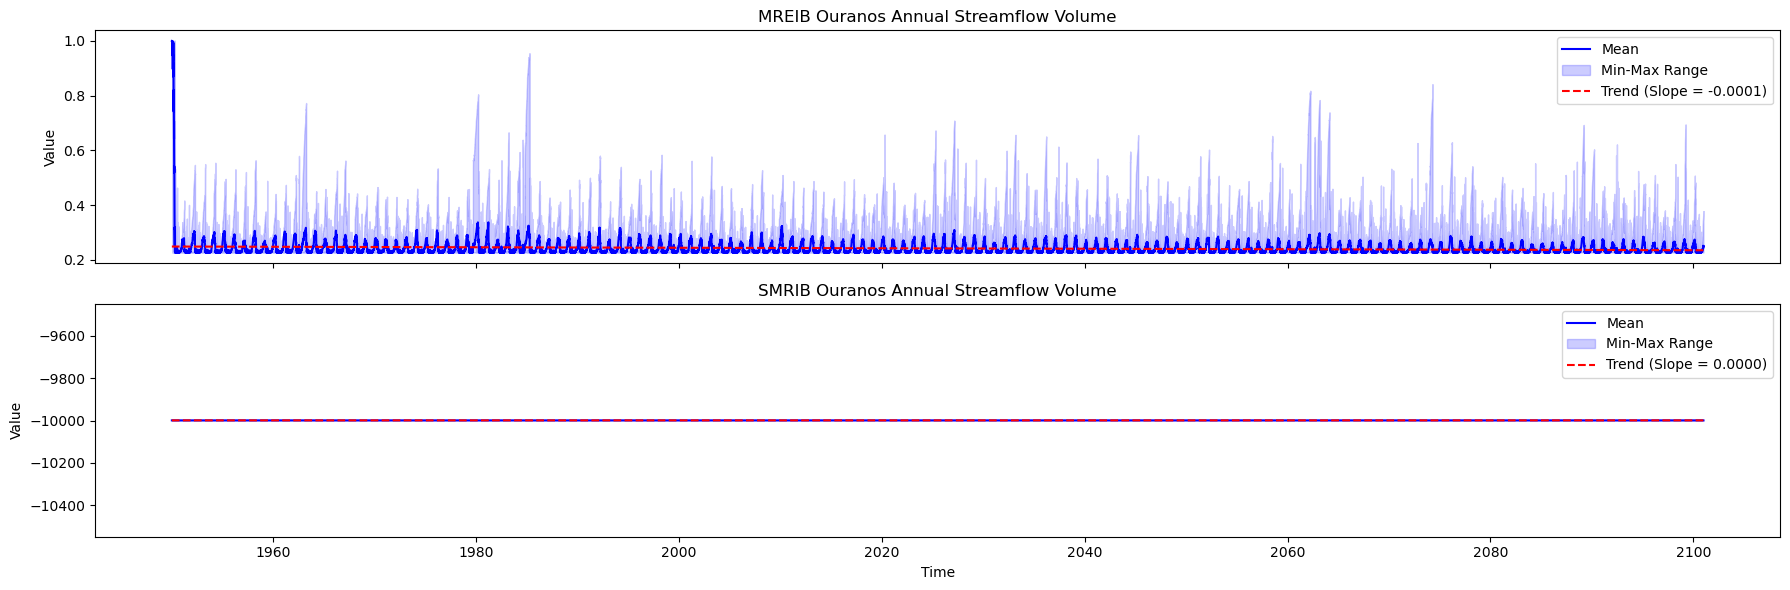

In [14]:
plot_ensemble_timeseries(milk_official_ensemble, stm_official_ensemble, 1950, 2100)

In [ ]:
# plot_historical_timeseries(mreib_historical, smrib_historical, start_year=1980, end_year=2050)

In [ ]:
plot_ensemble_timeseries(milk_annual_mean, stm_annual_mean, start_year, end_year)

In [ ]:
# plot_historical_timeseries(hist_milk_annual_sum, hist_stm_annual_sum, start_year=1980, end_year=2050)